<div dir="rtl">

# 01 — استكشاف بيانات DDXPlus

الهدف من هذا النوتبوك: تحميل داتاسِت DDXPlus وفهم بنيته (الأمراض، الأدلة/الأعراض، التشخيص التفاضلي، توزيع الحالات) فقط.

**لا يوجد هنا أي تدريب لنموذج ولا أي كود API.** التدريب سيكون في `02_train.ipynb` لاحقاً.

</div>

In [1]:
import ast
import json
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

RANDOM_STATE = 42
DATA_RAW = Path("../data/raw")

<div dir="rtl">

## مصدر البيانات وتحميلها عبر Figshare API

- **Figshare article ID**: `22687585` ("DDXPlus Dataset (English)")
- **API**: `https://api.figshare.com/v2/articles/22687585`
- **التوثيق الكامل**: <https://github.com/mila-iqia/ddxplus>
- تفاصيل الملفات وبصمات SHA-256 موثّقة في `data/MANIFEST.md`

الدالة أدناه تقرأ قائمة الملفات من الـAPI مباشرة (بدل تثبيت روابط تحميل قد تتغيّر)، وتفكّ ضغط
أرشيفات `patients` (zip) تلقائياً إلى CSV. إذا كان الملف موجوداً مسبقاً في `data/raw/` فلا تُعيد تحميله.

</div>

In [2]:
FIGSHARE_ARTICLE_ID = 22687585
FIGSHARE_API = f"https://api.figshare.com/v2/articles/{FIGSHARE_ARTICLE_ID}"


def download_ddxplus(data_raw: Path = DATA_RAW, force: bool = False) -> None:
    data_raw.mkdir(parents=True, exist_ok=True)
    meta = requests.get(FIGSHARE_API, timeout=30).json()

    for file_info in meta["files"]:
        name = file_info["name"]
        url = file_info["download_url"]
        # أرشيفات patients.zip تُفكّ إلى CSV مباشرة (انظر data/MANIFEST.md)
        target_name = name[:-4] + ".csv" if name.endswith(".zip") else name
        target = data_raw / target_name

        if target.exists() and not force:
            print(f"موجود مسبقاً، تخطّي: {target_name}")
            continue

        print(f"تحميل {name} ...")
        resp = requests.get(url, timeout=300)
        resp.raise_for_status()

        if name.endswith(".zip"):
            zip_path = data_raw / name
            zip_path.write_bytes(resp.content)
            with zipfile.ZipFile(zip_path) as zf:
                inner_name = zf.namelist()[0]
                with zf.open(inner_name) as src, open(target, "wb") as dst:
                    dst.write(src.read())
            zip_path.unlink()
        else:
            target.write_bytes(resp.content)

        print(f"  -> {target}")


download_ddxplus()

موجود مسبقاً، تخطّي: release_evidences.json
موجود مسبقاً، تخطّي: release_test_patients.csv
موجود مسبقاً، تخطّي: release_train_patients.csv
موجود مسبقاً، تخطّي: release_validate_patients.csv
موجود مسبقاً، تخطّي: release_conditions.json


In [3]:
expected_files = [
    "release_conditions.json",
    "release_evidences.json",
    "release_train_patients.csv",
    "release_validate_patients.csv",
]

missing = [f for f in expected_files if not (DATA_RAW / f).exists()]
if missing:
    print("ملفات ناقصة في data/raw/:")
    for f in missing:
        print(" -", f)
else:
    print("كل الملفات المطلوبة موجودة في data/raw/.")

كل الملفات المطلوبة موجودة في data/raw/.


<div dir="rtl">

## الحالات المرضية (conditions) والأعراض/الأدلة (evidences)

</div>

In [4]:
with open(DATA_RAW / "release_conditions.json", encoding="utf-8") as f:
    conditions = json.load(f)

with open(DATA_RAW / "release_evidences.json", encoding="utf-8") as f:
    evidences = json.load(f)

print(f"عدد الحالات المرضية (conditions): {len(conditions)}")
print(f"عدد الأعراض/الأدلة المعرَّفة (evidences): {len(evidences)}")

عدد الحالات المرضية (conditions): 49
عدد الأعراض/الأدلة المعرَّفة (evidences): 223


In [5]:
# عيّنة من بنية حالة مرضية واحدة
sample_condition_key = next(iter(conditions))
print(sample_condition_key)
conditions[sample_condition_key]

Spontaneous pneumothorax


{'condition_name': 'Spontaneous pneumothorax',
 'cond-name-fr': 'Pneumothorax spontané',
 'cond-name-eng': 'Spontaneous pneumothorax',
 'icd10-id': 'J93',
 'symptoms': {'E_55': {},
  'E_53': {},
  'E_57': {},
  'E_54': {},
  'E_59': {},
  'E_56': {},
  'E_58': {},
  'E_66': {},
  'E_220': {},
  'E_218': {},
  'E_14': {},
  'E_151': {}},
 'antecedents': {'E_79': {},
  'E_165': {},
  'E_21': {},
  'E_123': {},
  'E_204': {}},
 'severity': 2}

In [6]:
# عيّنة من بنية دليل/عرض واحد
sample_evidence_key = next(iter(evidences))
print(sample_evidence_key)
evidences[sample_evidence_key]

E_91


{'name': 'E_91',
 'code_question': 'E_91',
 'question_fr': 'Avez-vous objectivé ou ressenti de la fièvre?',
 'question_en': 'Do you have a fever (either felt or measured with a thermometer)?',
 'is_antecedent': False,
 'default_value': 0,
 'value_meaning': {},
 'possible-values': [],
 'data_type': 'B'}

<div dir="rtl">

## جدول الأمراض الـ49 (من release_conditions.json)

⚠️ **ملاحظة معمارية مهمة (تخص مرحلة الفرز/Triage لاحقاً)**: حقل `severity` في DDXPlus **معكوس** —
القيمة **الأصغر تعني خطورة أعلى** (1 = الأخطر طبياً، 5 = الأخف). هذا عكس الحدس المعتاد (حيث الأكبر = الأخطر
عادة)، ويجب الانتباه له عند بناء أي منطق أعلام حمراء أو ترتيب حسب الخطورة، تجنباً لانتهاك القاعدة الذهبية في
`CLAUDE.md`: **"القواعد ترفع درجة الخطورة، ولا تخفضها أبداً"**. التحقق العملي من الانعكاس في الخلية التالية.

</div>

In [7]:
diseases_df = pd.DataFrame(
    [
        {
            "condition_key": key,
            "condition_name": v.get("condition_name"),
            "icd10_id": v.get("icd10-id"),
            "severity": v.get("severity"),
        }
        for key, v in conditions.items()
    ]
).sort_values("severity").reset_index(drop=True)

print(f"عدد الأمراض: {len(diseases_df)}")
diseases_df

عدد الأمراض: 49


,condition_key,condition_name,icd10_id,severity
0,Possible NSTEMI / STEMI,Possible NSTEMI / STEMI,I21,1
1,Ebola,Ebola,a98.4,1
2,Acute pulmonary edema,Acute pulmonary edema,J81.0,1
3,Larygospasm,Larygospasm,J38.5,1
4,Anaphylaxis,Anaphylaxis,T78.0,1
5,Spontaneous pneumothorax,Spontaneous pneumothorax,J93,2
6,Pulmonary embolism,Pulmonary embolism,i26,2
7,Stable angina,Stable angina,I20.9,2
8,Unstable angina,Unstable angina,I20.0,2
9,Myocarditis,Myocarditis,I51.4,2


In [8]:
# تحقق عملي من انعكاس severity: هل القيمة 1 فعلاً تخص أمراضاً طارئة، والقيمة 5 أمراضاً خفيفة؟
print(f"أعلى خطورة (severity={diseases_df['severity'].min()}):")
print(diseases_df.loc[diseases_df["severity"] == diseases_df["severity"].min(), "condition_name"].tolist())

print(f"\nأقل خطورة (severity={diseases_df['severity'].max()}):")
print(diseases_df.loc[diseases_df["severity"] == diseases_df["severity"].max(), "condition_name"].tolist())

أعلى خطورة (severity=1):
['Possible NSTEMI / STEMI', 'Ebola', 'Acute pulmonary edema', 'Larygospasm', 'Anaphylaxis']

أقل خطورة (severity=5):
['Panic attack', 'Chronic rhinosinusitis', 'URTI']


<div dir="rtl">

## بيانات المرضى (train split فقط لهذه المرحلة)

</div>

In [9]:
train_df = pd.read_csv(DATA_RAW / "release_train_patients.csv")
train_df.shape

(1025602, 6)

In [10]:
train_df.head()

,AGE,DIFFERENTIAL_DIAGNOSIS,SEX,PATHOLOGY,EVIDENCES,INITIAL_EVIDENCE
0,18,"[['Bronchitis', 0.19171203430383882], ['Pneumo...",M,URTI,"['E_48', 'E_50', 'E_53', 'E_54_@_V_161', 'E_54...",E_91
1,21,"[['HIV (initial infection)', 0.518950056440760...",M,HIV (initial infection),"['E_9', 'E_27', 'E_50', 'E_51', 'E_53', 'E_54_...",E_50
2,19,"[['Bronchitis', 0.11278064619119596], ['Pneumo...",F,Pneumonia,"['E_53', 'E_54_@_V_179', 'E_54_@_V_192', 'E_55...",E_77
3,34,"[['URTI', 0.23859396799565236], ['Cluster head...",F,URTI,"['E_48', 'E_53', 'E_54_@_V_183', 'E_55_@_V_89'...",E_53
4,36,"[['URTI', 0.23677812769175735], ['Influenza', ...",M,URTI,"['E_49', 'E_50', 'E_53', 'E_54_@_V_183', 'E_55...",E_201


In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025602 entries, 0 to 1025601
Data columns (total 6 columns):
 #   Column                  Non-Null Count    Dtype 
---  ------                  --------------    ----- 
 0   AGE                     1025602 non-null  int64 
 1   DIFFERENTIAL_DIAGNOSIS  1025602 non-null  object
 2   SEX                     1025602 non-null  object
 3   PATHOLOGY               1025602 non-null  object
 4   EVIDENCES               1025602 non-null  object
 5   INITIAL_EVIDENCE        1025602 non-null  object
dtypes: int64(1), object(5)
memory usage: 46.9+ MB


<div dir="rtl">

## تحويل الأعمدة النصية (EVIDENCES / DIFFERENTIAL_DIAGNOSIS)

العمودان مخزَّنان كنص يمثّل بنية بايثون (قائمة رموز، أو قائمة أزواج [مرض، احتمال]).
نحوّلهما مرة واحدة عبر `ast.literal_eval` إلى أعمدة بايثون فعلية لإعادة استخدامها في بقية النوتبوك.

</div>

In [12]:
train_df["EVIDENCES_PARSED"] = train_df["EVIDENCES"].apply(ast.literal_eval)
train_df["DIFFERENTIAL_DIAGNOSIS_PARSED"] = train_df["DIFFERENTIAL_DIAGNOSIS"].apply(ast.literal_eval)

print(type(train_df["EVIDENCES_PARSED"].iloc[0]), train_df["EVIDENCES_PARSED"].iloc[0][:5])
print(type(train_df["DIFFERENTIAL_DIAGNOSIS_PARSED"].iloc[0]), train_df["DIFFERENTIAL_DIAGNOSIS_PARSED"].iloc[0][:3])

<class 'list'> ['E_48', 'E_50', 'E_53', 'E_54_@_V_161', 'E_54_@_V_183']
<class 'list'> [['Bronchitis', 0.19171203430383882], ['Pneumonia', 0.17579340398940366], ['URTI', 0.1607809719801254]]


<div dir="rtl">

## توزيع الأمراض (PATHOLOGY)

</div>

In [13]:
pathology_counts = train_df["PATHOLOGY"].value_counts()
print(f"عدد الأمراض الفريدة في الداتاسِت: {pathology_counts.shape[0]}")
pathology_counts.head(20)

عدد الأمراض الفريدة في الداتاسِت: 49


PATHOLOGY
URTI                        64368
Viral pharyngitis           61642
Anemia                      50665
HIV (initial infection)     29013
Localized edema             27825
Anaphylaxis                 27718
Pulmonary embolism          27468
Influenza                   26812
Bronchitis                  26400
Allergic sinusitis          26203
Acute dystonic reactions    25982
GERD                        25979
Acute otitis media          25917
Pneumonia                   25761
Panic attack                25019
Acute laryngitis            24129
Guillain-Barré syndrome     22867
Pericarditis                22785
Sarcoidosis                 21285
Possible NSTEMI / STEMI     21260
Name: count, dtype: int64

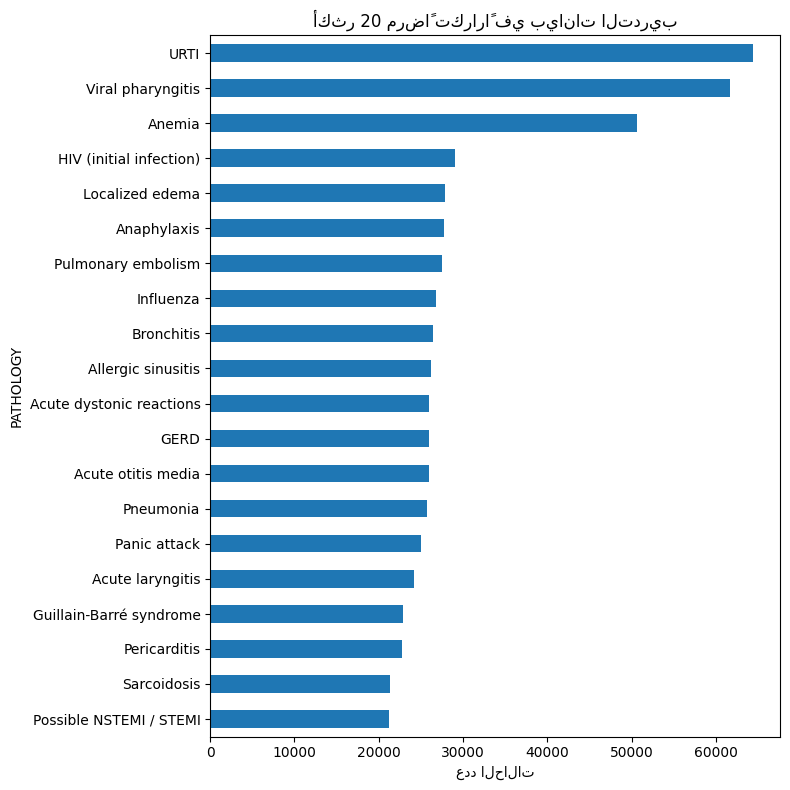

In [14]:
pathology_counts.head(20).plot(kind="barh", figsize=(8, 8))
plt.gca().invert_yaxis()
plt.xlabel("عدد الحالات")
plt.title("أكثر 20 مرضاً تكراراً في بيانات التدريب")
plt.tight_layout()
plt.show()

In [15]:
largest_class = pathology_counts.idxmax()
smallest_class = pathology_counts.idxmin()
imbalance_ratio = pathology_counts.max() / pathology_counts.min()

print(f"أكبر فئة: {largest_class} — {pathology_counts.max()} حالة")
print(f"أصغر فئة: {smallest_class} — {pathology_counts.min()} حالة")
print(f"نسبة الاختلال بين الطبقات (أكبر/أصغر): {imbalance_ratio:.1f}x")

أكبر فئة: URTI — 64368 حالة
أصغر فئة: Bronchiolitis — 261 حالة
نسبة الاختلال بين الطبقات (أكبر/أصغر): 246.6x


<div dir="rtl">

## توزيع الجنس والعمر

</div>

In [16]:
train_df["SEX"].value_counts()

SEX
F    527798
M    497804
Name: count, dtype: int64

In [17]:
train_df["AGE"].describe()

count    1.025602e+06
mean     3.971484e+01
std      2.271728e+01
min      0.000000e+00
25%      2.200000e+01
50%      3.900000e+01
75%      5.600000e+01
max      1.090000e+02
Name: AGE, dtype: float64

<div dir="rtl">

## القيم المفقودة

</div>

In [18]:
train_df.isna().sum()

AGE                              0
DIFFERENTIAL_DIAGNOSIS           0
SEX                              0
PATHOLOGY                        0
EVIDENCES                        0
INITIAL_EVIDENCE                 0
EVIDENCES_PARSED                 0
DIFFERENTIAL_DIAGNOSIS_PARSED    0
dtype: int64

<div dir="rtl">

## تحليل الأدلة (EVIDENCES)

كل عنصر في `EVIDENCES_PARSED` قد يكون:
- كوداً بسيطاً لدليل ثنائي: `E_48`
- أو كوداً مركّباً بصيغة `<evidence>_@_<value>` لدليل متعدد القيم — وقد يتكرر نفس الدليل الأساسي
  بعدة قيم مختلفة لنفس المريض (مثال: `E_54_@_V_161`, `E_54_@_V_180`).

لذلك نميّز بين مقياسين مختلفين تماماً:
- **N_EVIDENCE_ITEMS**: طول القائمة الخام — يُحصي كل قيمة مركّبة كعنصر منفصل.
- **N_DISTINCT_EVIDENCES**: عدد الأدلة **الأساسية** الفريدة بعد فصل `_@_` — وهو المقياس القابل للمقارنة
  بالمتوسط الموثَّق رسمياً لعدد الأدلة لكل مريض (**13.56** حسب توثيق DDXPlus).

</div>

In [19]:
def base_evidence(code: str) -> str:
    return code.split("_@_")[0]


train_df["N_EVIDENCE_ITEMS"] = train_df["EVIDENCES_PARSED"].apply(len)
train_df["N_DISTINCT_EVIDENCES"] = train_df["EVIDENCES_PARSED"].apply(
    lambda ev_list: len({base_evidence(e) for e in ev_list})
)

train_df[["N_EVIDENCE_ITEMS", "N_DISTINCT_EVIDENCES"]].describe()

,N_EVIDENCE_ITEMS,N_DISTINCT_EVIDENCES
count,1.025602e+06,1.025602e+06
mean,1.969099e+01,1.533341e+01
std,8.043986e+00,5.542726e+00
min,2.000000e+00,2.000000e+00
25%,1.400000e+01,1.200000e+01
50%,2.000000e+01,1.500000e+01
75%,2.500000e+01,1.900000e+01
max,4.700000e+01,3.900000e+01


In [20]:
# مقارنة N_DISTINCT_EVIDENCES بالمتوسط الموثَّق رسمياً في توثيق DDXPlus
official_mean_evidences = 13.56
computed_mean = train_df["N_DISTINCT_EVIDENCES"].mean()

print(f"متوسط N_DISTINCT_EVIDENCES المحسوب من train: {computed_mean:.2f}")
print(f"المتوسط الموثَّق رسمياً: {official_mean_evidences}")
print(f"الفرق: {computed_mean - official_mean_evidences:+.2f}")

متوسط N_DISTINCT_EVIDENCES المحسوب من train: 15.33
المتوسط الموثَّق رسمياً: 13.56
الفرق: +1.77


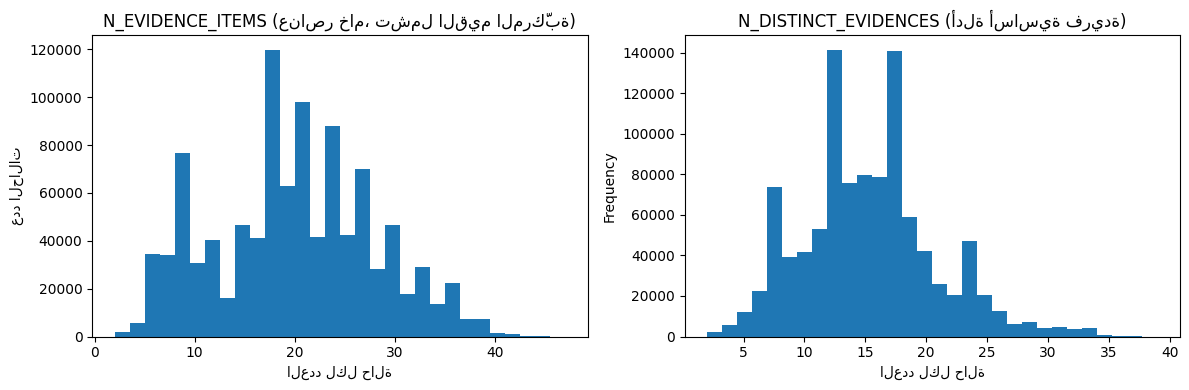

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df["N_EVIDENCE_ITEMS"].plot(kind="hist", bins=30, ax=axes[0])
axes[0].set_title("N_EVIDENCE_ITEMS (عناصر خام، تشمل القيم المركّبة)")
axes[0].set_xlabel("العدد لكل حالة")
axes[0].set_ylabel("عدد الحالات")

train_df["N_DISTINCT_EVIDENCES"].plot(kind="hist", bins=30, ax=axes[1])
axes[1].set_title("N_DISTINCT_EVIDENCES (أدلة أساسية فريدة)")
axes[1].set_xlabel("العدد لكل حالة")

plt.tight_layout()
plt.show()

In [22]:
all_evidence_items_used = set()
all_distinct_evidences_used = set()
for ev_list in train_df["EVIDENCES_PARSED"]:
    all_evidence_items_used.update(ev_list)
    all_distinct_evidences_used.update(base_evidence(e) for e in ev_list)

print(f"عدد العناصر الخام الفريدة (بما فيها القيم المركّبة _@_): {len(all_evidence_items_used)}")
print(f"عدد الأدلة الأساسية الفريدة (بعد فصل _@_): {len(all_distinct_evidences_used)}")
print(f"عدد الأدلة المعرَّفة في release_evidences.json: {len(evidences)}")

عدد العناصر الخام الفريدة (بما فيها القيم المركّبة _@_): 515
عدد الأدلة الأساسية الفريدة (بعد فصل _@_): 223
عدد الأدلة المعرَّفة في release_evidences.json: 223


<div dir="rtl">

### فرضية `default_value`: هل استبعاد القيم الافتراضية يقرّب المتوسط من 13.56؟

كل دليل في `release_evidences.json` له `default_value` (القيمة "المحايدة"/غياب الإجابة الفعلية،
مثل `'NA'` أو `'nowhere'` للأدلة متعددة القيم، أو `0` للأدلة الثنائية). الفرضية: ربما المتوسط الرسمي
13.56 يُحتسب بعد استبعاد عناصر `EVIDENCES` التي تساوي قيمتها `default_value` الخاص بدليلها (أي غير معلوماتية).

- دليل ثنائي (`data_type='B'`, `default_value=0`): مجرّد ظهوره في القائمة يعني قيمة=1 → دائماً غير افتراضي.
- دليل متعدد القيم (`data_type='M'`, مثل `_@_V_xxx`): يُستبعد فقط إن كانت القيمة المختارة == `default_value`.

</div>

In [23]:
evidence_defaults = {k: v.get("default_value") for k, v in evidences.items()}


def is_informative(item: str) -> bool:
    if "_@_" not in item:
        return True  # دليل ثنائي: الظهور نفسه يعني قيمة=1 (مختلفة عن default=0)
    base, value = item.split("_@_", 1)
    return value != evidence_defaults.get(base)


train_df["N_INFORMATIVE"] = train_df["EVIDENCES_PARSED"].apply(
    lambda ev_list: sum(is_informative(e) for e in ev_list)
)
train_df["N_INFORMATIVE"].describe()

count    1.025602e+06
mean     1.787584e+01
std      7.699184e+00
min      1.000000e+00
25%      1.200000e+01
50%      1.700000e+01
75%      2.400000e+01
max      4.400000e+01
Name: N_INFORMATIVE, dtype: float64

In [24]:
computed_informative_mean = train_df["N_INFORMATIVE"].mean()
print(f"متوسط N_INFORMATIVE المحسوب: {computed_informative_mean:.2f}")
print(f"المتوسط الموثَّق رسمياً: {official_mean_evidences}")
print(f"الفرق: {computed_informative_mean - official_mean_evidences:+.2f}")

متوسط N_INFORMATIVE المحسوب: 17.88
المتوسط الموثَّق رسمياً: 13.56
الفرق: +4.32


<div dir="rtl">

**نتيجة الفرضية: لم تُطابق.** `N_INFORMATIVE` المحسوب (~17.88) **أبعد** عن المتوسط الرسمي (13.56) من
`N_DISTINCT_EVIDENCES` (~15.33) — أي أن استبعاد القيم الافتراضية لا يقرّب الرقم، بل يزيد الفجوة. سبب ذلك على الأرجح
أن أغلب `EVIDENCES` في train هي أدلة ثنائية (تُحسب دائماً كمعلوماتية في هذا التعريف)، بينما الاستبعاد الفعلي يطال فقط
جزءاً صغيراً من الأدلة متعددة القيم. الفرضية بصيغتها هذه **مرفوضة**؛ يبقى `N_DISTINCT_EVIDENCES` (فصل `_@_` فقط)
أقرب تقدير متوفر لدينا، رغم عدم تطابقه الكامل مع 13.56. سبب الفجوة المتبقية (+1.77) غير محسوم من داخل البيانات وحدها.

</div>

<div dir="rtl">

### تشخيص أخير للفجوة: تقسيم N_DISTINCT_EVIDENCES إلى أعراض (symptoms) وسوابق (antecedents)

كل دليل في `release_evidences.json` يحمل حقل `is_antecedent`. الفرضية: ربما التوثيق الرسمي يُبلّغ عن
متوسطين منفصلين — أحدهما للأعراض الإيجابية (symptoms) والآخر للسوابق التاريخية (antecedents) — وليس
مجموعهما كرقم واحد. نقارن بـ **10.07** (أعراض) و**3.49** (سوابق)، وبأرباع مرجعية `(1, 10, 13, 17, 36)`.

</div>

In [25]:
def split_evidence_bases(ev_list):
    bases = {base_evidence(e) for e in ev_list}
    symptoms = {b for b in bases if not evidences.get(b, {}).get("is_antecedent", False)}
    antecedents = bases - symptoms
    return len(symptoms), len(antecedents)


split_result = train_df["EVIDENCES_PARSED"].apply(split_evidence_bases)
train_df["N_DISTINCT_SYMPTOMS"] = split_result.apply(lambda t: t[0])
train_df["N_DISTINCT_ANTECEDENTS"] = split_result.apply(lambda t: t[1])

train_df[["N_DISTINCT_SYMPTOMS", "N_DISTINCT_ANTECEDENTS"]].describe()

,N_DISTINCT_SYMPTOMS,N_DISTINCT_ANTECEDENTS
count,1.025602e+06,1.025602e+06
mean,1.091619e+01,4.417220e+00
std,5.327221e+00,2.200801e+00
min,1.000000e+00,1.000000e+00
25%,8.000000e+00,3.000000e+00
50%,1.000000e+01,4.000000e+00
75%,1.300000e+01,6.000000e+00
max,2.700000e+01,1.200000e+01


In [26]:
official_symptoms_mean = 10.07
official_antecedents_mean = 3.49

symptoms_mean = train_df["N_DISTINCT_SYMPTOMS"].mean()
antecedents_mean = train_df["N_DISTINCT_ANTECEDENTS"].mean()

print(f"متوسط الأعراض (N_DISTINCT_SYMPTOMS): {symptoms_mean:.2f} — الرسمي: {official_symptoms_mean} — الفرق: {symptoms_mean - official_symptoms_mean:+.2f}")
print(f"متوسط السوابق (N_DISTINCT_ANTECEDENTS): {antecedents_mean:.2f} — الرسمي: {official_antecedents_mean} — الفرق: {antecedents_mean - official_antecedents_mean:+.2f}")
print(f"مجموع المتوسطين: {symptoms_mean + antecedents_mean:.2f} (للمقارنة بـ N_DISTINCT_EVIDENCES: {train_df['N_DISTINCT_EVIDENCES'].mean():.2f})")

متوسط الأعراض (N_DISTINCT_SYMPTOMS): 10.92 — الرسمي: 10.07 — الفرق: +0.85
متوسط السوابق (N_DISTINCT_ANTECEDENTS): 4.42 — الرسمي: 3.49 — الفرق: +0.93
مجموع المتوسطين: 15.33 (للمقارنة بـ N_DISTINCT_EVIDENCES: 15.33)


In [27]:
official_quartiles = [1, 10, 13, 17, 36]  # min, 25%, 50%, 75%, max
computed_quartiles = train_df["N_DISTINCT_SYMPTOMS"].quantile([0, 0.25, 0.5, 0.75, 1.0]).tolist()

quartile_comparison = pd.DataFrame(
    {
        "الرسمي": official_quartiles,
        "المحسوب (N_DISTINCT_SYMPTOMS)": computed_quartiles,
    },
    index=["min", "25%", "50%", "75%", "max"],
)
quartile_comparison["الفرق"] = (
    quartile_comparison["المحسوب (N_DISTINCT_SYMPTOMS)"] - quartile_comparison["الرسمي"]
)
quartile_comparison

,الرسمي,المحسوب (N_DISTINCT_SYMPTOMS),الفرق
min,1,1.0,0.0
25%,10,8.0,-2.0
50%,13,10.0,-3.0
75%,17,13.0,-4.0
max,36,27.0,-9.0


<div dir="rtl">

**الخلاصة النهائية**: تقسيم `N_DISTINCT_EVIDENCES` إلى أعراض/سوابق قرّب المتوسطات بشكل واضح — الأعراض ~10.92
مقابل 10.07 الرسمي (فرق ~+0.85 فقط، تراجعاً من +1.77)، والسوابق ~4.42 مقابل 3.49 (فرق ~+0.93). لكن الأرباع لم
تتطابق تماماً، خصوصاً عند القيم العليا (الحد الأقصى المحسوب أقل من المرجعي 36)، ما يرجّح أن الفرق المتبقي مصدره
اختلاف بسيط في تعريف/تجميع الرقم الرسمي (مثل احتسابه على كامل الداتاسِت train+validate+test بدل train وحدها) —
وليس خطأً في منهجيتنا.

**نغلق هذا التحقيق هنا. نعتمد أرقامنا المُعاد حسابها (`N_DISTINCT_SYMPTOMS`، `N_DISTINCT_ANTECEDENTS`،
`N_DISTINCT_EVIDENCES`) كمرجع رسمي للمشروع من الآن فصاعداً، لا أرقام التوثيق الخارجي.**

</div>

<div dir="rtl">

## الدليل الابتدائي (INITIAL_EVIDENCE)

العرض/السؤال الذي بدأ به الحوار المحاكى مع المريض — عادة هو الشكوى الرئيسية التي يبدأ بها المريض حديثه.

</div>

In [28]:
print(f"عدد قيم INITIAL_EVIDENCE الفريدة: {train_df['INITIAL_EVIDENCE'].nunique()}")
train_df["INITIAL_EVIDENCE"].value_counts().head(20)

عدد قيم INITIAL_EVIDENCE الفريدة: 96


INITIAL_EVIDENCE
E_53     188480
E_66      86081
E_201     75741
E_181     49190
E_91      42317
E_129     26917
E_45      24216
E_151     23220
E_50      20673
E_77      20508
E_155     18769
E_148     18541
E_214     18539
E_89      17857
E_218     16344
E_194     15696
E_82      15279
E_97      15231
E_220     13573
E_144     12670
Name: count, dtype: int64

In [29]:
# هل الدليل الابتدائي جزء دوماً من قائمة EVIDENCES الكاملة لنفس الحالة؟ (عيّنة للسرعة)
def initial_in_evidences(row) -> bool:
    initial_base = base_evidence(row["INITIAL_EVIDENCE"])
    evidence_bases = {base_evidence(e) for e in row["EVIDENCES_PARSED"]}
    return initial_base in evidence_bases


sample = train_df.sample(n=50_000, random_state=RANDOM_STATE)
match_rate = sample.apply(initial_in_evidences, axis=1).mean()
print(f"نسبة الحالات (عيّنة 50 ألف، random_state={RANDOM_STATE}) التي يكون فيها INITIAL_EVIDENCE ضمن EVIDENCES: {match_rate:.1%}")

نسبة الحالات (عيّنة 50 ألف، random_state=42) التي يكون فيها INITIAL_EVIDENCE ضمن EVIDENCES: 100.0%


<div dir="rtl">

## تحليل التشخيص التفاضلي (DIFFERENTIAL_DIAGNOSIS)

قائمة أزواج `[اسم المرض, الاحتمال]` مرتّبة تنازلياً حسب الاحتمال لكل حالة.

</div>

In [30]:
train_df["DIFFERENTIAL_DIAGNOSIS_PARSED"].iloc[0]

[['Bronchitis', 0.19171203430383882],
 ['Pneumonia', 0.17579340398940366],
 ['URTI', 0.1607809719801254],
 ['Bronchiectasis', 0.12429044460990353],
 ['Tuberculosis', 0.11367177304035844],
 ['Influenza', 0.11057936110639896],
 ['HIV (initial infection)', 0.07333003867293564],
 ['Chagas', 0.04984197229703562]]

In [31]:
train_df["n_differential"] = train_df["DIFFERENTIAL_DIAGNOSIS_PARSED"].apply(len)
train_df["n_differential"].describe()

count    1.025602e+06
mean     9.179170e+00
std      6.023057e+00
min      1.000000e+00
25%      4.000000e+00
50%      8.000000e+00
75%      1.300000e+01
max      3.400000e+01
Name: n_differential, dtype: float64

In [32]:
# هل التشخيص الفعلي (PATHOLOGY) هو الأعلى احتمالاً دوماً ضمن DIFFERENTIAL_DIAGNOSIS؟
top_diagnosis = train_df["DIFFERENTIAL_DIAGNOSIS_PARSED"].apply(
    lambda dd: max(dd, key=lambda pair: pair[1])[0] if dd else None
)
top_match_rate = (top_diagnosis == train_df["PATHOLOGY"]).mean()
print(f"نسبة الحالات التي يكون فيها PATHOLOGY هو الأعلى احتمالاً في DIFFERENTIAL_DIAGNOSIS: {top_match_rate:.1%}")

نسبة الحالات التي يكون فيها PATHOLOGY هو الأعلى احتمالاً في DIFFERENTIAL_DIAGNOSIS: 73.7%


<div dir="rtl">

## ملاحظات للمرحلة القادمة (بدون تنفيذ الآن)

- مصدر البيانات (Figshare article `22687585`، توثيق `mila-iqia/ddxplus`) وبصمات SHA-256 موثّقة في `data/MANIFEST.md`.
- ⚠️ `severity` في `release_conditions.json` **معكوسة** (1 = الأخطر، 5 = الأخف) — يجب الانتباه لهذا عند بناء `data/red_flags.yaml` لاحقاً.
- النطاق النهائي: الـ49 مرضاً **كاملة بلا تصفية** — الاختلال الشديد بين الفئات (~247x) يُعالَج عبر `class_weight`
  عند التدريب، وليس بحذف أمراض، حفاظاً على قابلية مقارنة النتائج بالأدبيات المنشورة على DDXPlus. لا حاجة لـ
  `data/diseases.yaml` كملف تصفية.
- جسر الترجمة العربي (`data/symptoms_ar.yaml`) خطوة منفصلة لاحقة، غير مطلوبة في هذا النوتبوك.
- `N_DISTINCT_EVIDENCES` (وتفريعاته `N_DISTINCT_SYMPTOMS` / `N_DISTINCT_ANTECEDENTS`) هي الأرقام المُعتمَدة
  رسمياً لهذا المشروع لعدد الأدلة لكل حالة — ليس طول القائمة الخام `EVIDENCES` ولا أرقام التوثيق الخارجي حرفياً.
- لا تدريب نموذج هنا — ذلك في `02_train.ipynb`.

</div>

In [33]:
import json
conds = json.load(open("../data/raw/release_conditions.json", encoding="utf-8"))
for c in sorted(conds.values(), key=lambda x: x["severity"]):
    print(c["severity"], c["cond-name-eng"], c["icd10-id"], sep=" | ")

1 | Anaphylaxis | T78.0
1 | Larygospasm | J38.5
1 | Ebola | a98.4
1 | Possible NSTEMI / STEMI | I21
1 | Acute pulmonary edema | J81.0
2 | Spontaneous pneumothorax | J93
2 | Boerhaave | K22.3
2 | Epiglottitis | J05.1
2 | Guillain-Barré syndrome | G61.0
2 | Croup | J05.0
2 | PSVT | I47.1
2 | Scombroid food poisoning | T61.1
2 | Myocarditis | I51.4
2 | Acute dystonic reactions | G24.02
2 | Unstable angina | I20.0
2 | Stable angina | I20.9
2 | Pulmonary embolism | i26
3 | Cluster headache | g44.009
3 | Spontaneous rib fracture | S22.9
3 | GERD | K21
3 | HIV (initial infection) | B20
3 | Inguinal hernia | K40
3 | Myasthenia gravis | G70.0
3 | Atrial fibrillation | I48.91
3 | Bronchiectasis | J47
3 | Chagas | B57
3 | Tuberculosis | a15
3 | Bronchospasm / acute asthma exacerbation | J45
3 | Acute COPD exacerbation / infection | j44.1
3 | Influenza | j11.1
3 | Pneumonia | j17, j18
3 | Bronchiolitis | j21
3 | Pulmonary neoplasm | c34
3 | Pancreatic neoplasm | c25
4 | Anemia | D64.9
4 | Viral ph